In [3]:
import numpy as np
import pandas as pd
import glob
import os

In [4]:
import matplotlib.pyplot as plt

from sklearn.decomposition import NMF, LatentDirichletAllocation, MiniBatchNMF
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

In [5]:
folder_path = '../data/raw/agora/fulltext/*.txt'
all_files = glob.glob(folder_path)

data = []

for file in all_files:
    with open(file, "r") as text:
        text_content = text.read()

    source_file = os.path.basename(file)
    data.append((source_file, text_content))

df = pd.DataFrame(data, columns=['source_file', 'raw_text'])

df.head()

,source_file,raw_text
0,1053.txt,"Introduction\nIn recent months, generative AI ..."
1,1721.txt,Section 30. The Managed Care Reform and Pa...
2,6728.txt,AN ACT\n\nProviding for disclosures and safegu...
3,2566.txt,(a) In General.--In addition to amounts otherw...
4,2572.txt,119th CONGRESS\n 1st Session\n ...


In [6]:
len(df)

1251

In [7]:
test = df.head()

In [8]:
stats = test.describe()
print(stats)

       source_file                                           raw_text
count            5                                                  5
unique           5                                                  5
top       1053.txt  Introduction\nIn recent months, generative AI ...
freq             1                                                  1


### **Code example from:** 
[Scikit_learn topic extraction example](https://scikit-learn.org/stable/auto_examples/applications/plot_topics_extraction_with_nmf_lda.html)

In [21]:
def plot_top_words(model, feature_names, n_top_words, title):
    fig, axes = plt.subplots(2, 5, figsize=(30, 15), sharex=True)
    axes = axes.flatten()
    for topic_idx, topic in enumerate(model.components_):
        top_features_ind = topic.argsort()[-n_top_words:]
        top_features = feature_names[top_features_ind]
        weights = topic[top_features_ind]

        ax = axes[topic_idx]
        ax.barh(top_features, weights, height=0.7)
        ax.set_title(f"Topic {topic_idx + 1}", fontdict={"fontsize": 30})
        ax.tick_params(axis="both", which="major", labelsize=20)
        for i in "top right left".split():
            ax.spines[i].set_visible(False)
        fig.suptitle(title, fontsize=40)

    plt.subplots_adjust(top=0.90, bottom=0.05, wspace=0.90, hspace=0.3)
    plt.show()

In [9]:
n_samples = 2000
n_features = 1000
n_components = 10
n_top_words = 20
batch_size = 128

In [15]:
text_strings = df['raw_text'].tolist()

In [16]:
vectorizer = CountVectorizer()
X = vectorizer.fit_transform(text_strings)
vocab = vectorizer.get_feature_names_out()
doc_freq = (X > 0).sum(axis=0).A1
df_summary = pd.DataFrame({'Term': vocab, 'Document_Frequency': doc_freq})
print(df_summary)

              Term  Document_Frequency
0               00                  24
1              000                 335
2             0001                   1
3              001                  12
4            00135                   1
...            ...                 ...
22930         ﬁrst                   1
22931         ﬂaws                   1
22932  ﾒautomation                   1
22933  ﾒbackground                   1
22934       ﾒimage                   1

[22935 rows x 2 columns]


In [32]:
tf_vectorizer = CountVectorizer(
    max_df=0.95, min_df=2, max_features=n_features, stop_words="english"
)
tf = tf_vectorizer.fit_transform(text_strings)
vocab = tf_vectorizer.get_feature_names_out()
doc_freq = (tf > 0).sum(axis=0).A1
df_summary = pd.DataFrame({'Term': vocab, 'Document_Frequency': doc_freq})
print(df_summary)

        Term  Document_Frequency
0        000                 335
1         10                 553
2        101                 152
3         11                 302
4         12                 329
..       ...                 ...
995  working                 166
996    world                 133
997  written                 222
998     year                 644
999    years                 523

[1000 rows x 2 columns]


In [29]:
tfidf_vectorizer = TfidfVectorizer(
    max_df=0.95, min_df=2, max_features=n_features, stop_words="english"
)
tfidf = tfidf_vectorizer.fit_transform(text_strings)

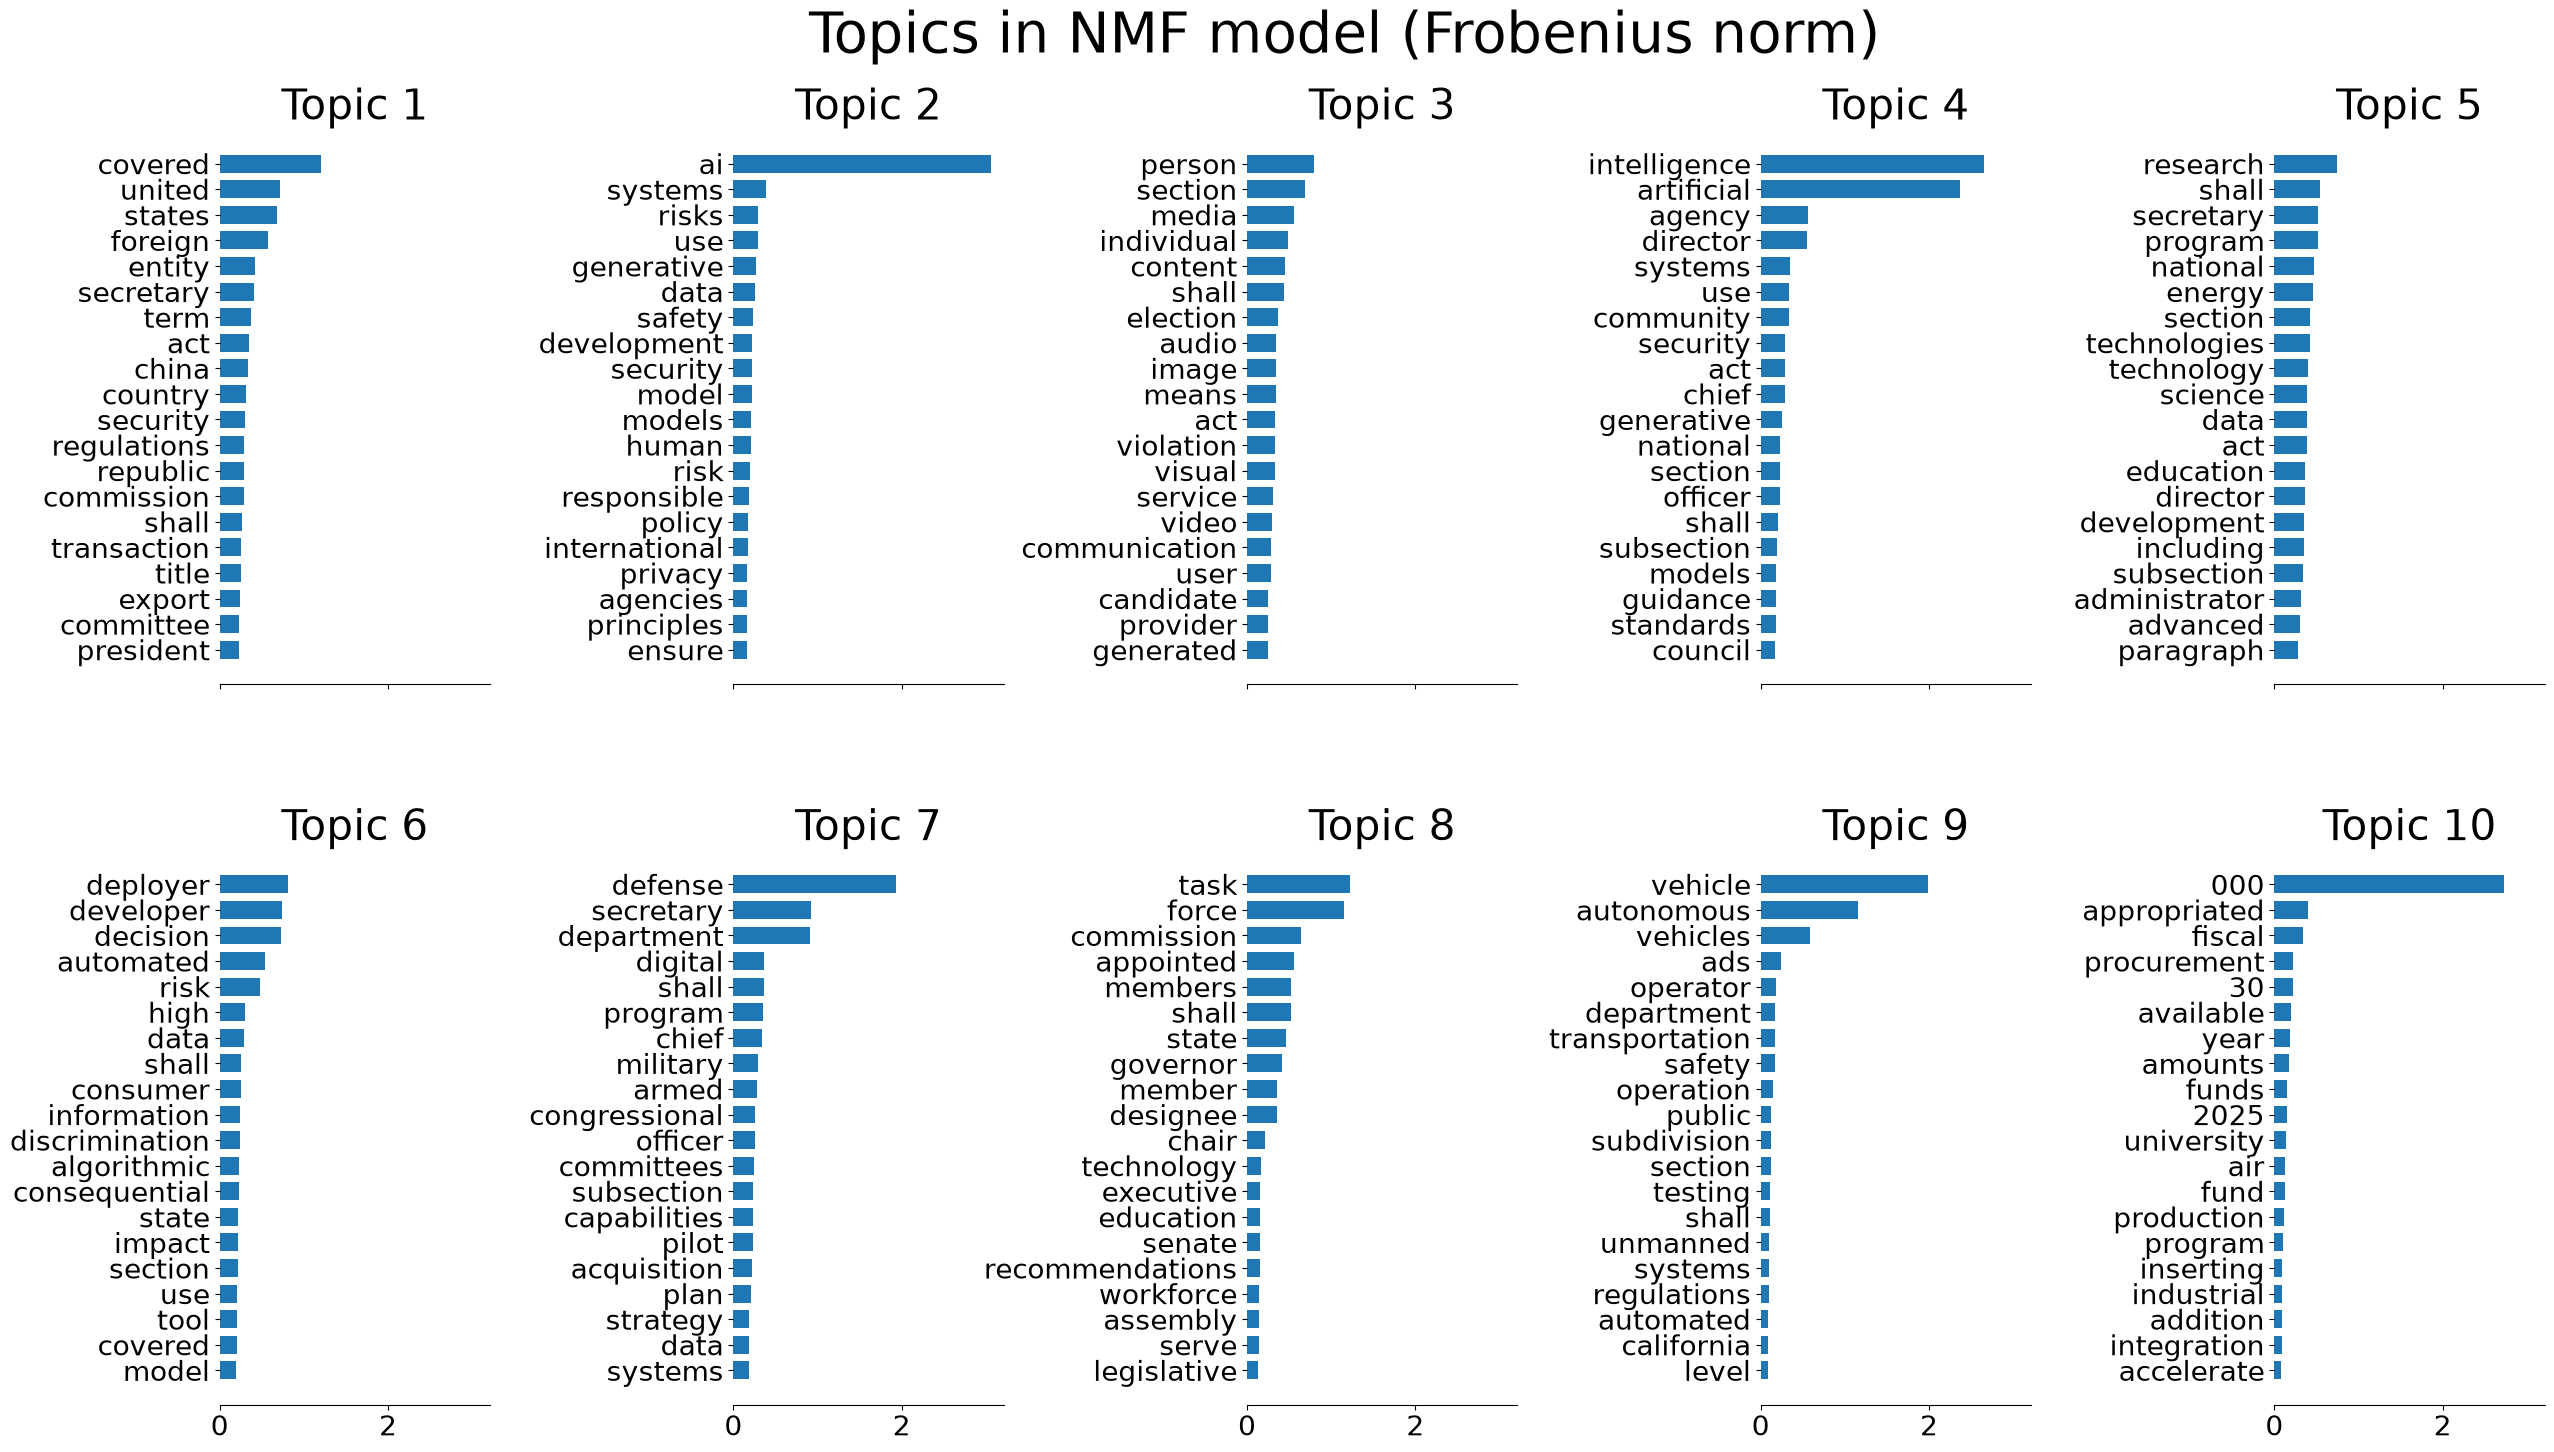

In [22]:
nmf = NMF(
    n_components=n_components,
    random_state=1,
    beta_loss="frobenius",
    alpha_W=0.00005,
    alpha_H=0.00005,
    l1_ratio=1,
).fit(tfidf)


tfidf_feature_names = tfidf_vectorizer.get_feature_names_out()
plot_top_words(
    nmf, tfidf_feature_names, n_top_words, "Topics in NMF model (Frobenius norm)"
)

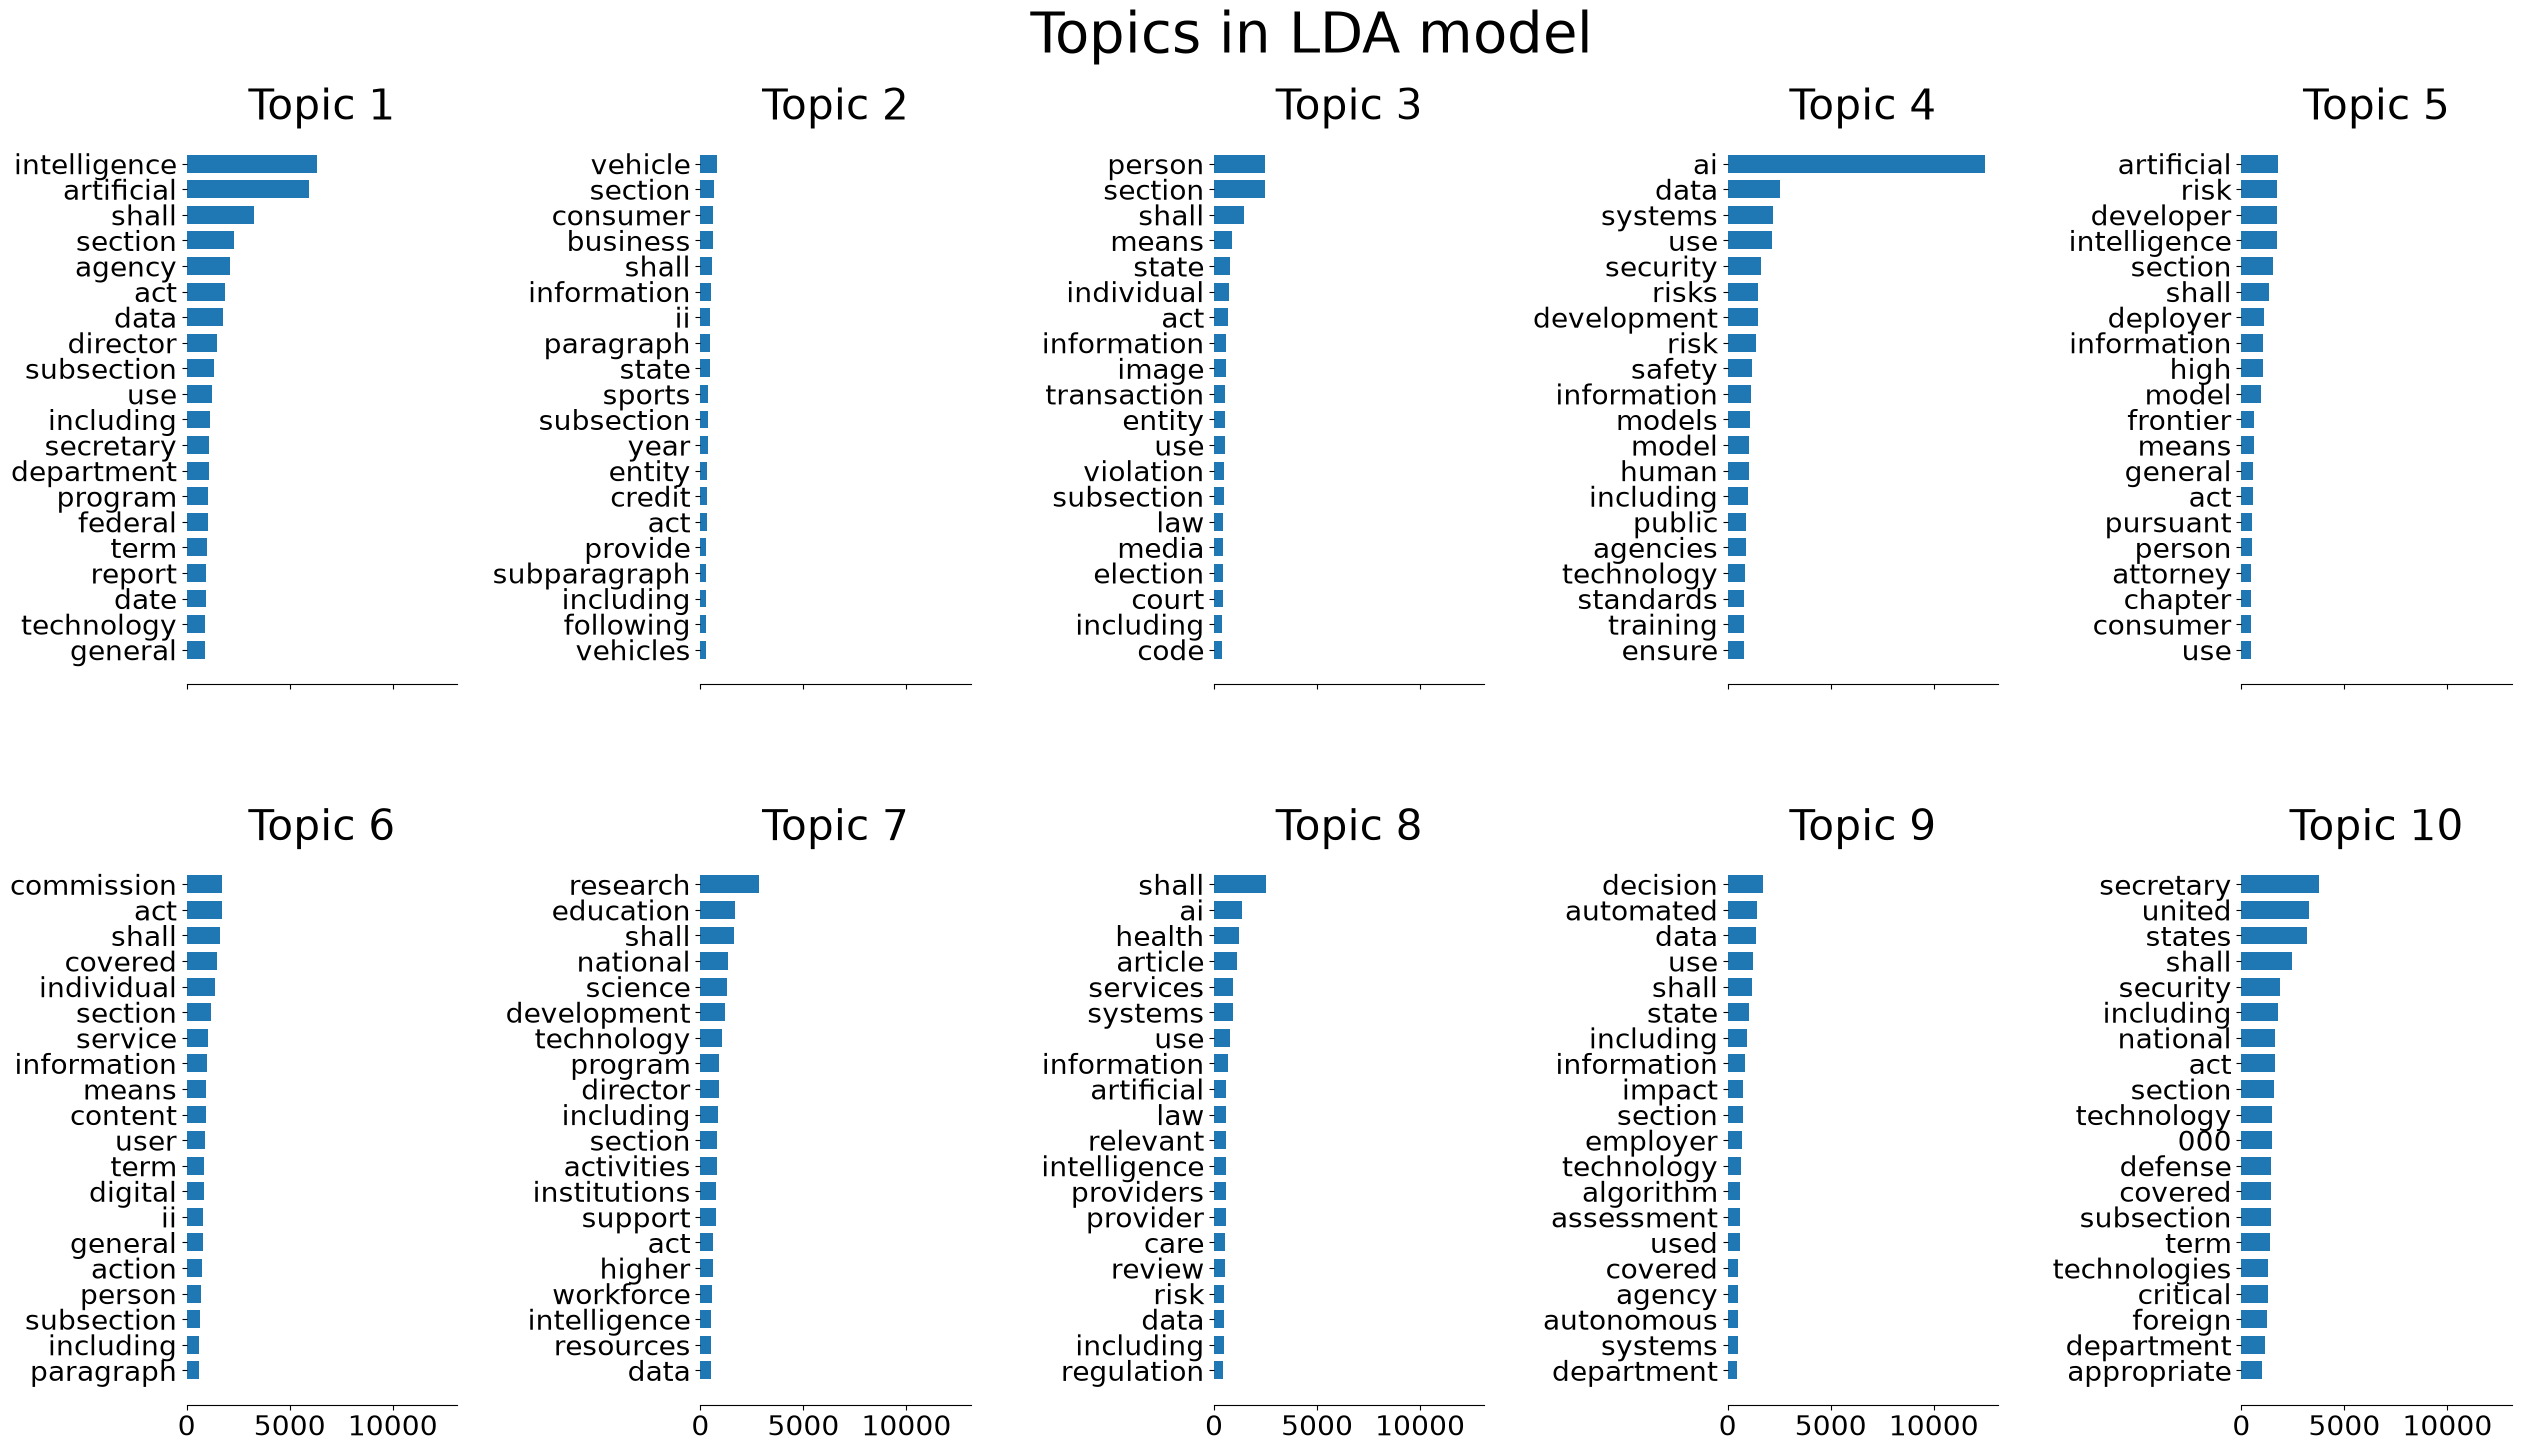

In [31]:
lda = LatentDirichletAllocation(
    n_components=n_components,
    max_iter=5,
    learning_method="online",
    learning_offset=50.0,
    random_state=0,
)

lda.fit(tf)

tf_feature_names = tf_vectorizer.get_feature_names_out()
plot_top_words(lda, tf_feature_names, n_top_words, "Topics in LDA model")